In [7]:
import torch
import torch.nn as nn
from torchvision.datasets import CIFAR10
from torchvision.transforms import Compose, Normalize, ToTensor
from torch.utils.data import DataLoader
from torch.nn import init
import matplotlib.pyplot as plt
device = 'cuda:0'

In [8]:
# only has train and test set
# 1D data, so mean and std parameter contain only one element.
data_transform = Compose(transforms=[ToTensor(),
                                     Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])

# prepare data
trainset = CIFAR10(root='data',
                        train=True,
                        transform=data_transform,
                        download=True)

testset = CIFAR10(root='data',
                       train=False,
                       transform=data_transform)

# convert to DataLoader. Shuffle train set and doesn't turn on it for test set
trainloader = DataLoader(dataset=trainset,
                         batch_size=1024,
                         shuffle=True,
                         num_workers=10,
                         drop_last=True)

testloader = DataLoader(dataset=testset,
                        batch_size=1024,
                        shuffle=False,
                        num_workers=10,
                        drop_last=True)


# for debug
for _, (X_sample,y_sample) in enumerate(trainloader):
    print(X_sample.shape, y_sample.shape)
    break

torch.Size([1024, 3, 32, 32]) torch.Size([1024])


In [9]:
# setup for CNNs training - solution 02: add Batch Norm when the distribution of kernel was changed
classes = 10

block1 = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding='same'),  nn.ReLU(inplace=True), nn.BatchNorm2d(num_features=64),
    nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding='same'), nn.ReLU(inplace=True), nn.BatchNorm2d(num_features=64),
    nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding='same'), nn.ReLU(inplace=True), nn.BatchNorm2d(num_features=64),
    nn.MaxPool2d(kernel_size=2, stride=2)
)

block2 = nn.Sequential(
    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding='same'),  nn.ReLU(inplace=True), nn.BatchNorm2d(num_features=128),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding='same'), nn.ReLU(inplace=True), nn.BatchNorm2d(num_features=128),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding='same'), nn.ReLU(inplace=True), nn.BatchNorm2d(num_features=128),
    nn.MaxPool2d(kernel_size=2, stride=2)
)


block3 = nn.Sequential(
    nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding='same'), nn.ReLU(inplace=True), nn.BatchNorm2d(num_features=256),
    nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding='same'), nn.ReLU(inplace=True), nn.BatchNorm2d(num_features=256),
    nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding='same'), nn.ReLU(inplace=True), nn.BatchNorm2d(num_features=256),
    nn.MaxPool2d(kernel_size=2, stride=2)
)

block4 = nn.Sequential(
    nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding='same'), nn.ReLU(inplace=True), nn.BatchNorm2d(num_features=512),
    nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding='same'), nn.ReLU(inplace=True), nn.BatchNorm2d(num_features=512),
    nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding='same'), nn.ReLU(inplace=True), nn.BatchNorm2d(num_features=512),
    nn.MaxPool2d(kernel_size=2, stride=2)
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=512*2*2, out_features=512), nn.ReLU(),
    nn.Linear(in_features=512, out_features=classes)
)


class CNNsTraining(nn.Module):
    def __init__(self):
        super(CNNsTraining, self).__init__()
        self.block1 = block1
        self.block2 = block2
        self.block3 = block3
        self.block4 = block4
        self.dense_layer = classifier

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.dense_layer(x)
        return x

In [10]:
# prepare to train
model = CNNsTraining().to(device)
criterion = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-3)

# parameters
total_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", total_params)

Total parameters: 8879754


In [11]:

def acc(logits_matrix, true_label_vector):
    """
    Calculate accuracy for model
    - logits_matrix:        a matrix which haves num_of_batch rows, and num_classes columns.
    - true_label_vector:    a vector contains true class of all samples in batch.
    """
    # get max value for each rows
    maxxing_vector = torch.argmax(logits_matrix, dim=1)

    # get the similar numbers between true and pred label, then calculates sum
    sum_elements = len(true_label_vector)
    similar_elements = (maxxing_vector == true_label_vector).sum()

    # accuracy
    acc_value = similar_elements/sum_elements
    return acc_value

In [12]:
# training
epochs = 50

# tracking best value
best_train_acc = 0
best_test_acc = 0
best_train_loss = 1000000
best_test_loss = 1000000

# train -- logging
train_losses = []
test_losses = []
train_accs = []
test_accs = []

for epoch in range(epochs):

    # batch logging
    train_loss_batches = []
    test_loss_batches = []
    train_acc_batches = []
    test_acc_batches = []
    #--------train field--------#
    model.train()
    for _, (X_train_batch, y_train_batch) in enumerate(trainloader):

        # transform to GPU
        X_train_batch, y_train_batch = X_train_batch.to(device), y_train_batch.to(device)

        # forward
        y_train_batch_pred = model(X_train_batch)                # output: logits matrix
        train_loss_batch = criterion(y_train_batch_pred, y_train_batch)

        # backward
        optimizer.zero_grad()
        train_loss_batch.backward()
        optimizer.step()

        # save loss result
        loss_batch_value = train_loss_batch.item()
        train_loss_batches.append(loss_batch_value)

        # save metric result
        try:
            train_acc_batch = acc(logits_matrix=y_train_batch_pred,
                              true_label_vector= y_train_batch)
            train_acc_batches.append(train_acc_batch)

        except Exception as e:
            print(f'Failed to calculate metric for training: {e}')


    # loss: train epoch logging
    train_loss_epoch = sum(train_loss_batches)/len(train_loss_batches)
    train_losses.append(train_loss_epoch)
    if train_loss_epoch < best_train_loss:
        best_train_loss = train_loss_epoch

    # metric: train epoch logging
    train_acc_epoch = sum(train_acc_batches)/len(train_acc_batches)
    train_accs.append(train_acc_epoch)
    if train_acc_epoch > best_train_acc:
        best_train_acc = train_acc_epoch


    #---------test field--------#
    model.eval()
    for _, (X_test_batch, y_test_batch) in enumerate(testloader):

        # transform to GPU
        X_test_batch, y_test_batch = X_test_batch.to(device), y_test_batch.to(device)

        # testing
        y_test_batch_pred = model(X_test_batch)
        test_loss_batch = criterion(y_test_batch_pred, y_test_batch)

        # save loss result
        test_loss_batch_value = test_loss_batch.item()
        test_loss_batches.append(test_loss_batch_value)

        # save metric result
        test_acc_batch = acc(logits_matrix=y_test_batch_pred,
                             true_label_vector=y_test_batch)
        test_acc_batches.append(test_acc_batch)


    # loss: test epoch logging
    test_loss_epoch = sum(test_loss_batches)/len(test_loss_batches)
    test_losses.append(test_loss_epoch)
    if test_loss_epoch < best_test_loss:
        best_test_loss = test_loss_epoch

    # metric: test epoch logging
    test_acc_epoch = sum(test_acc_batches)/len(test_acc_batches)
    test_accs.append(test_acc_epoch)
    if test_acc_epoch > best_test_acc:
        best_test_acc = test_acc_epoch


    # log
    print(f'EPOCH {epoch + 1}:           train_loss = {train_loss_epoch},                 test_loss = {test_loss_epoch}')

EPOCH 1:           train_loss = 1.769000214835008,                 test_loss = 1.5134196281433105
EPOCH 2:           train_loss = 1.2162829389174779,                 test_loss = 1.1508693430158827
EPOCH 3:           train_loss = 0.9203881944219271,                 test_loss = 0.984003914727105
EPOCH 4:           train_loss = 0.7324749181667963,                 test_loss = 0.7654343512323167
EPOCH 5:           train_loss = 0.5720975908140341,                 test_loss = 0.6656655271848043
EPOCH 6:           train_loss = 0.4670696643491586,                 test_loss = 0.6497476233376397
EPOCH 7:           train_loss = 0.38465244695544243,                 test_loss = 0.6115727689531114
EPOCH 8:           train_loss = 0.2988311933974425,                 test_loss = 0.6259512172804939
EPOCH 9:           train_loss = 0.2408659728243947,                 test_loss = 0.6647186014387343
EPOCH 10:           train_loss = 0.20409152563661337,                 test_loss = 0.6032616297403971
EPOCH 11:

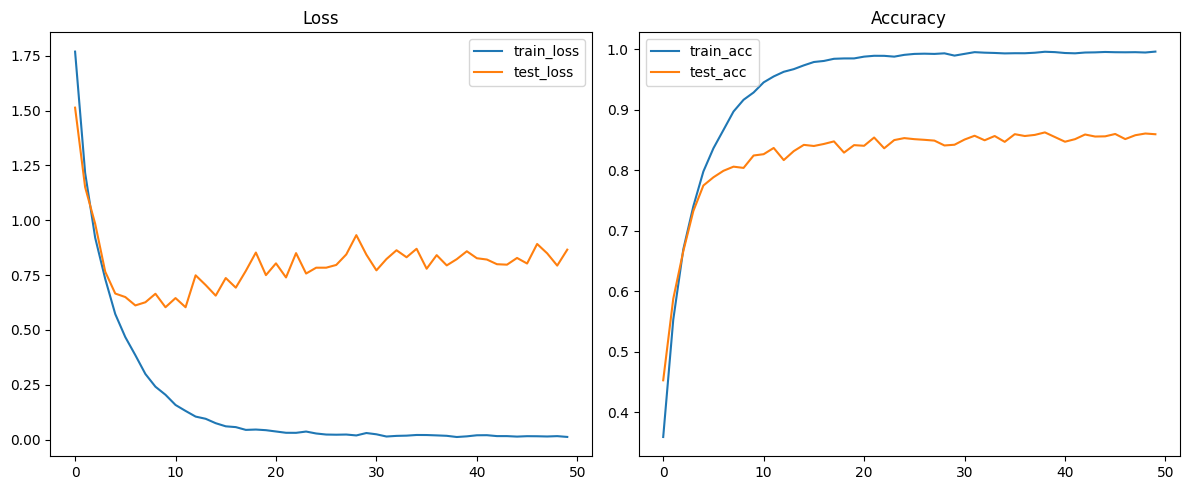

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Loss plot
ax1.plot([t.item() if torch.is_tensor(t) else t for t in train_losses], label='train_loss')
ax1.plot([t.item() if torch.is_tensor(t) else t for t in test_losses], label='test_loss')
ax1.legend()
ax1.set_title("Loss")

# Accuracy plot
ax2.plot([t.item() if torch.is_tensor(t) else t for t in train_accs], label='train_acc')
ax2.plot([t.item() if torch.is_tensor(t) else t for t in test_accs], label='test_acc')
ax2.legend()
ax2.set_title("Accuracy")

plt.tight_layout()
plt.show()

In [14]:
print("-------Best Performance--------\n")
print("Training Accuracy: {}".format(best_train_acc))
print("Training Loss: {}\n".format(best_train_loss))

print("Testing Accuracy: {}".format(best_test_acc))
print("Testing Loss: {}".format(best_test_loss))

-------Best Performance--------

Training Accuracy: 0.99609375
Training Loss: 0.011485438405846557

Testing Accuracy: 0.8625217080116272
Testing Loss: 0.6032058397928873
